In [25]:
import pickle
from collections import defaultdict 
import torch
from tqdm import tqdm
from minf.data import FieldDataset
from minf.models import Autoencoder, SirenNet
from minf.utils import plot_field
from torch.utils.data import DataLoader
import numpy as np
import umap
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

In [26]:
resolution = 16

df = pd.read_csv("../data/freesolv.csv")

smiles = df["smiles"].tolist()

fd = FieldDataset(smiles, resolution=resolution)
dl = DataLoader(fd, batch_size=4, shuffle=True)
dl_test = DataLoader(fd, batch_size=8, shuffle=False)

In [27]:
net = SirenNet(
    dim_in=4,
    dim_hidden=256,
    dim_out=1,
    num_layers=4,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

autoencoder = Autoencoder(
    net,
    in_channels=10,
    output_shape=[resolution, resolution, resolution, 10, 1],
    latent_dim=512,
)

autoencoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=autoencoder.parameters())

# Load the model
autoencoder.load_state_dict(torch.load("../models/freesolv_b.pt", weights_only=True))
autoencoder.cuda()

Autoencoder(
  (net): SirenNet(
    (layers): ModuleList(
      (0-3): 4 x Siren(
        (activation): Sine()
      )
    )
    (last_layer): Siren(
      (activation): Identity()
    )
  )
  (encoder): Encoder(
    (in_layer): Conv3d(10, 20, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_input): BatchNorm3d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (layer_1): Conv3d(20, 40, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_1): BatchNorm3d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (out_layer): Conv3d(40, 512, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_output): BatchNorm3d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pooling): AdaptiveAvgPool3d(output_size=1)
  )
  (modulator): Modulator(
    (layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=512, out_features=256, bias=True)
        (1): ReLU()
      )
      

yt : [INFO     ] 2025-02-11 23:33:13,856 Parameters: current_time              = 0.0                                  | 0/81 [00:00<?, ?it/s]
yt : [INFO     ] 2025-02-11 23:33:13,856 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:33:13,856 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:33:13,857 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:33:13,857 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:33:13,897 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:33:13,904 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:33:13,905 Creating volume
yt : [INFO     ] 2025-02-11 23:33:13,920 Creating transfer function
yt : [INFO     ] 2025-02-11 23:33:13,920 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


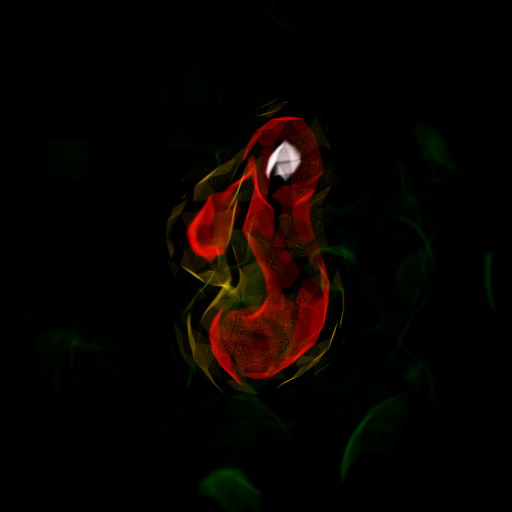

yt : [INFO     ] 2025-02-11 23:33:14,071 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:33:14,071 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:33:14,072 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:33:14,072 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:33:14,072 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:33:14,113 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:33:14,119 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:33:14,120 Creating volume
yt : [INFO     ] 2025-02-11 23:33:14,135 Creating transfer function
yt : [INFO     ] 2025-02-11 23:33:14,135 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


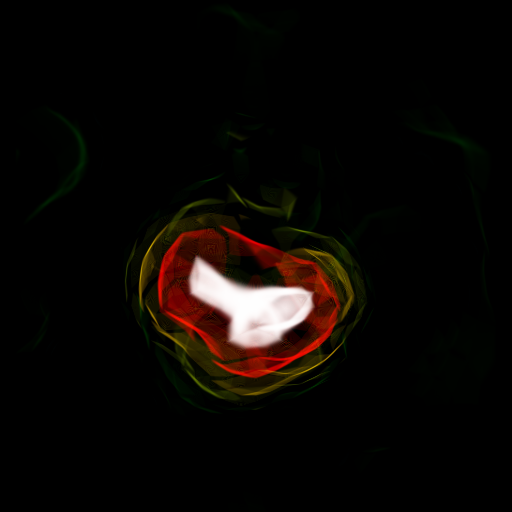

yt : [INFO     ] 2025-02-11 23:33:14,272 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:33:14,272 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:33:14,272 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:33:14,272 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:33:14,273 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:33:14,314 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:33:14,321 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:33:14,322 Creating volume
yt : [INFO     ] 2025-02-11 23:33:14,337 Creating transfer function
yt : [INFO     ] 2025-02-11 23:33:14,337 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


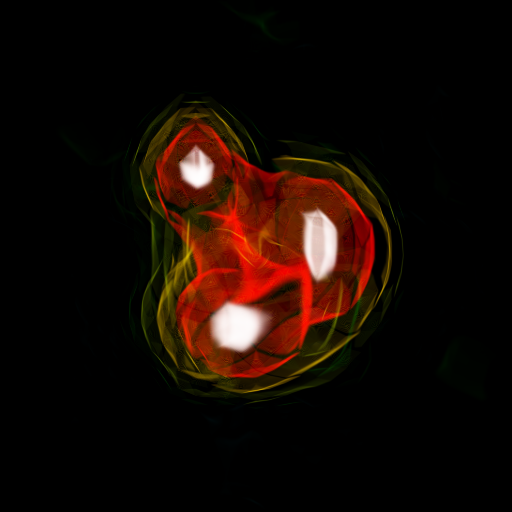

yt : [INFO     ] 2025-02-11 23:33:14,475 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:33:14,475 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:33:14,476 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:33:14,476 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:33:14,476 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:33:14,518 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:33:14,524 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:33:14,525 Creating volume
yt : [INFO     ] 2025-02-11 23:33:14,540 Creating transfer function
yt : [INFO     ] 2025-02-11 23:33:14,541 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


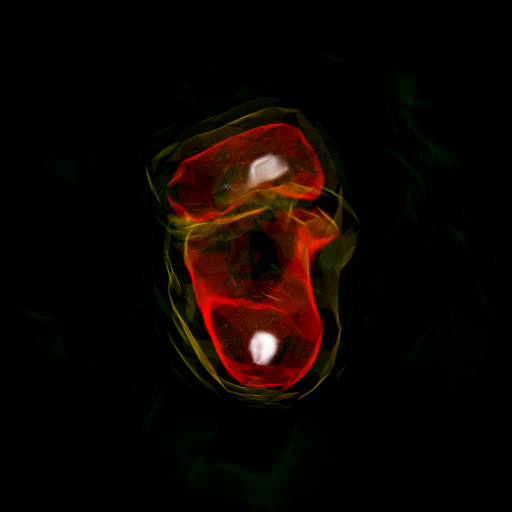

yt : [INFO     ] 2025-02-11 23:33:14,697 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:33:14,697 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:33:14,698 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:33:14,698 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:33:14,698 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:33:14,739 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:33:14,746 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:33:14,747 Creating volume
yt : [INFO     ] 2025-02-11 23:33:14,761 Creating transfer function
yt : [INFO     ] 2025-02-11 23:33:14,762 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


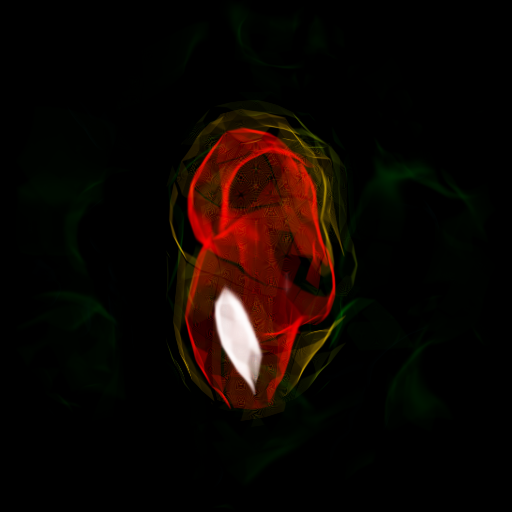

yt : [INFO     ] 2025-02-11 23:33:14,918 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:33:14,918 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:33:14,918 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:33:14,918 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:33:14,919 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:33:14,961 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:33:14,967 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:33:14,968 Creating volume
yt : [INFO     ] 2025-02-11 23:33:14,983 Creating transfer function
yt : [INFO     ] 2025-02-11 23:33:14,983 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


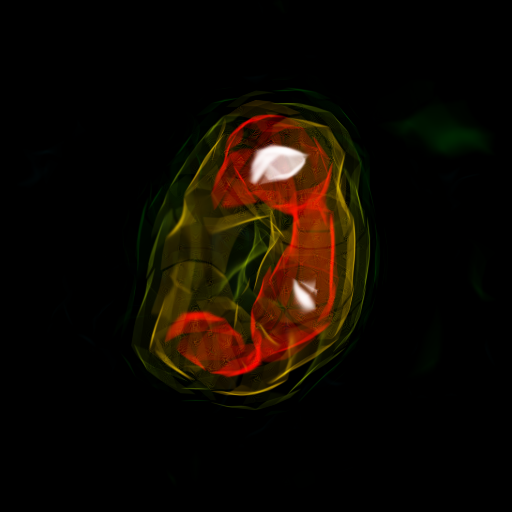

yt : [INFO     ] 2025-02-11 23:33:15,131 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:33:15,131 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:33:15,131 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:33:15,132 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:33:15,132 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:33:15,174 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:33:15,180 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:33:15,181 Creating volume
yt : [INFO     ] 2025-02-11 23:33:15,195 Creating transfer function
yt : [INFO     ] 2025-02-11 23:33:15,195 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


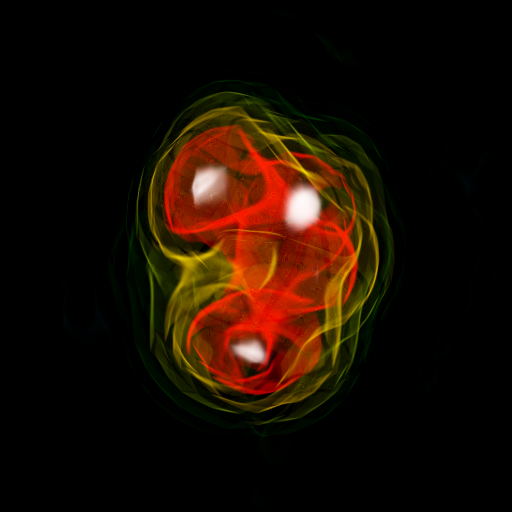

yt : [INFO     ] 2025-02-11 23:33:15,347 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 23:33:15,347 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2025-02-11 23:33:15,347 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 23:33:15,347 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 23:33:15,348 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 23:33:15,390 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 23:33:15,397 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 23:33:15,397 Creating volume
yt : [INFO     ] 2025-02-11 23:33:15,412 Creating transfer function
yt : [INFO     ] 2025-02-11 23:33:15,412 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


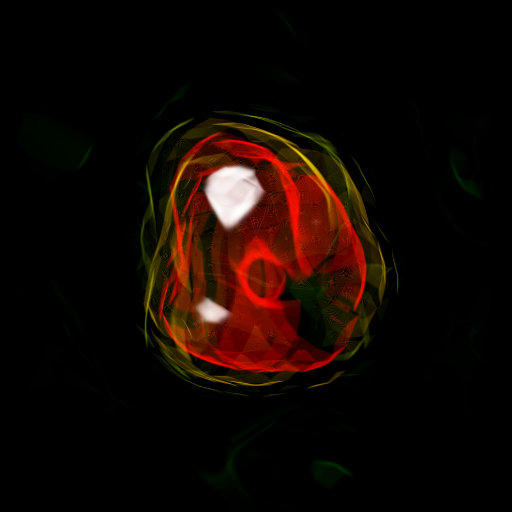

  0%|                                                                                                                 | 0/81 [00:01<?, ?it/s]


In [28]:
x = []
for batch in tqdm(dl_test, total=len(dl_test)):
    latents = autoencoder.encode(batch.cuda())
    predictions = autoencoder.predict(latents).cpu().detach().squeeze(-1)
    for pred in predictions:
        plot_field(pred[:, :, :, 0]).show()
    break

In [5]:
x = []
for batch in tqdm(dl_test, total=len(dl_test)):
    latents = autoencoder.encode(batch.cuda())
    for latent in latents:
        x.append(latent.cpu().detach().numpy())

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 81/81 [00:03<00:00, 26.09it/s]


In [9]:
y = df["freesolv"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1)
mlp = MLPRegressor(hidden_layer_sizes=(512,64,32), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Root Mean Squared Error: {rmse}')
print(f'R^2 Score: {r2}')

Root Mean Squared Error: 2.6497139274984165
R^2 Score: 0.38916210206183066


/home/daenu/micromamba/envs/minf/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


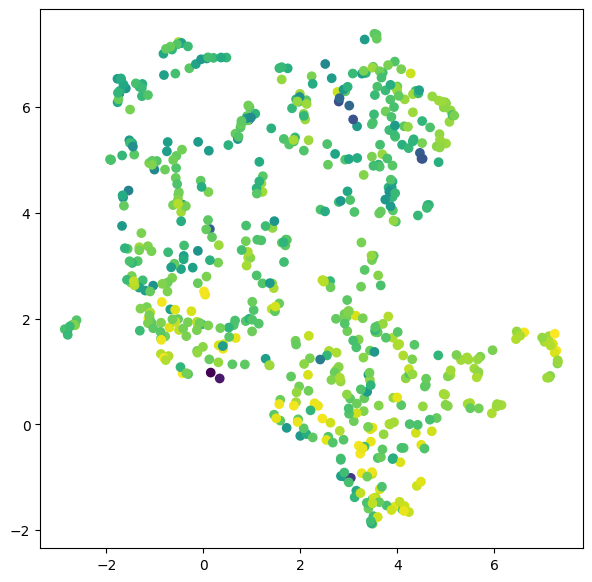

ExactMolWt


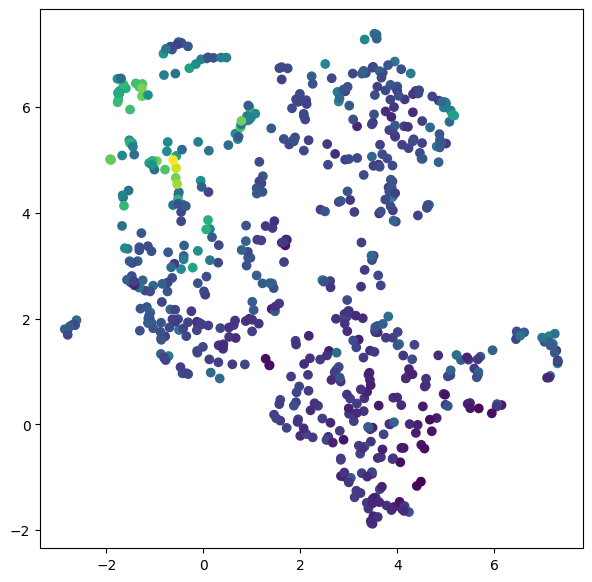

In [24]:
x_proj = umap.UMAP(n_neighbors=5).fit_transform(np.array(x))
y = df["freesolv"].to_numpy()
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(x_proj.T[0], x_proj.T[1], c=y)
plt.show()

y = defaultdict(list)

for smi in df["smiles"].tolist():
    mol = Chem.MolFromSmiles(smi)
    y["ExactMolWt"].append(rdMolDescriptors.CalcExactMolWt(mol))

for smi in df["smiles"].tolist():
    mol = Chem.MolFromSmiles(smi)
    # y[]rdMolDescriptors.CalcExactMolWt(mol))


for key, value in y.items():
    print(key)
    fig, ax = plt.subplots(figsize=(7, 7))
    
    ax.scatter(x_proj.T[0], x_proj.T[1], c=value)
    plt.show()